
Dataset Loaded Successfully!

First 5 Rows
   warehouse_inventory_level  handling_equipment_availability  \
0                 985.716862                         0.481294   
1                 985.716862                         0.481294   
2                 985.716862                         0.481294   
3                 396.700206                         0.620780   
4                 396.700206                         0.620780   

   order_fulfillment_status  weather_condition_severity  shipping_costs  \
0                  0.761166                    0.359066      456.503853   
1                  0.761166                    0.359066      456.503853   
2                  0.761166                    0.359066      456.503853   
3                  0.196594                    0.230660      640.408205   
4                  0.196594                    0.230660      640.408205   

   supplier_reliability_score  lead_time_days  historical_demand  \
0                    0.986064        2.128009 

/tmp/ipykernel_1272/3508109688.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1272/3508109688.py:63: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

warehouse_inventory_level          0
handling_equipment_availability    0
order_fulfillment_status           0
weather_condition_severity         0
shipping_costs                     0
supplier_reliability_score         0
lead_time_days                     0
historical_demand                  0
cargo_condition_status             0
route_risk_level                   0
customs_clearance_time             0
disruption_likelihood_score        0
delay_probability                  0
risk_classification                0
delivery_time_deviation            0
product_id                         0
supplier_id                        0
supplier_country                   0
dtype: int64

Duplicate Rows: 0
Dataset Shape After Removing Duplicates: (78047, 18)


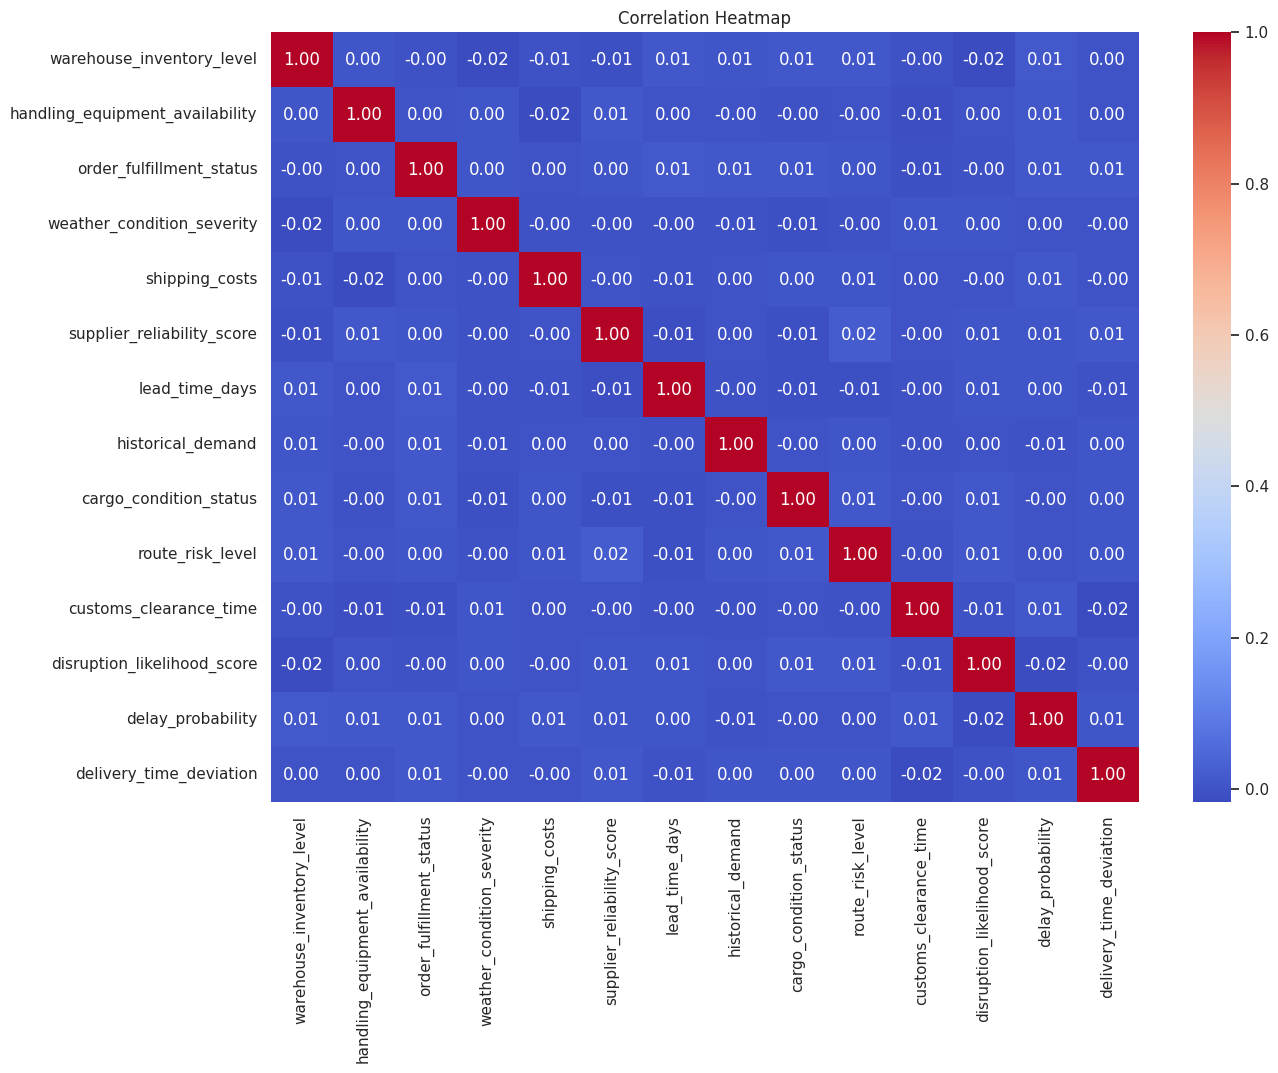

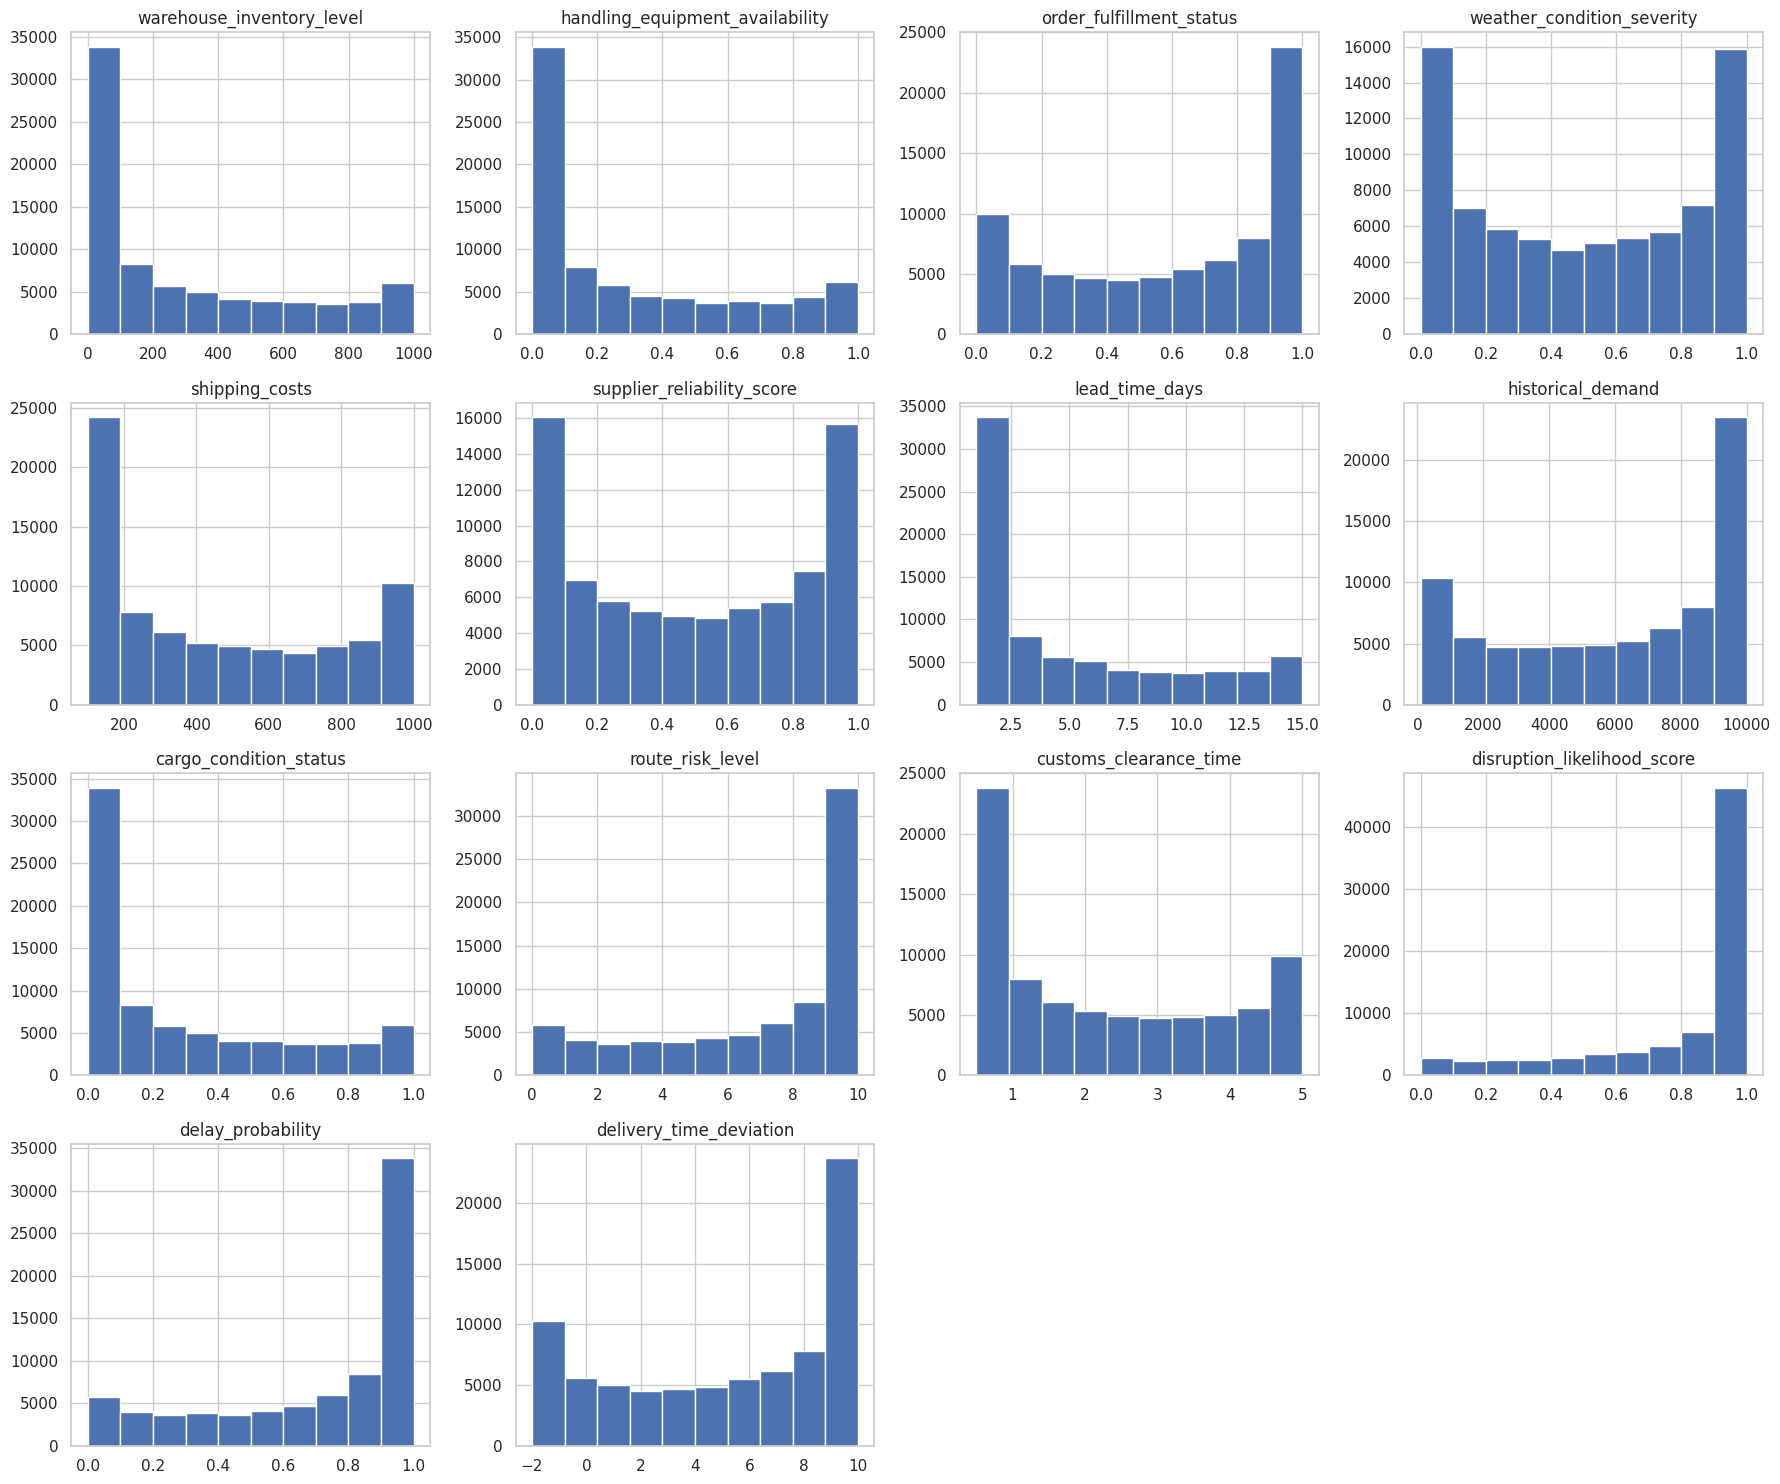

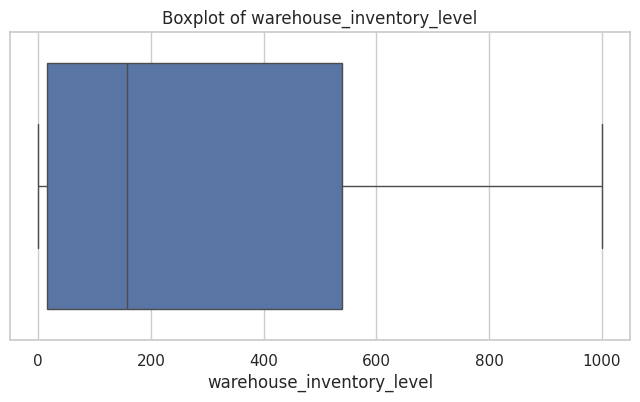

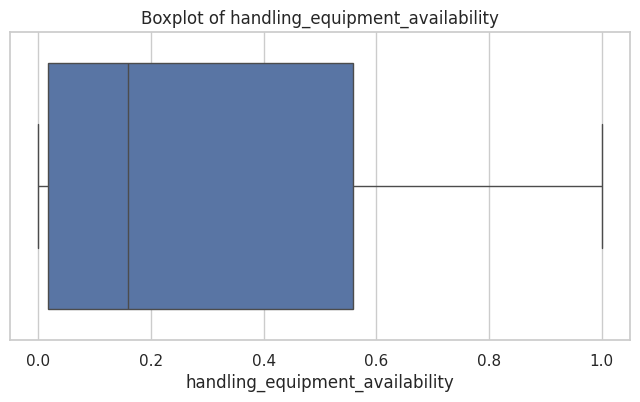

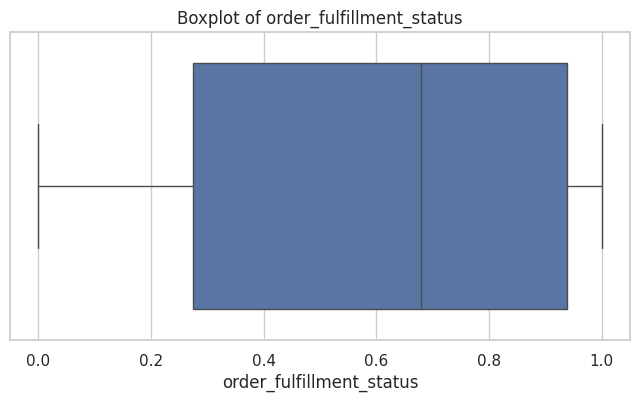

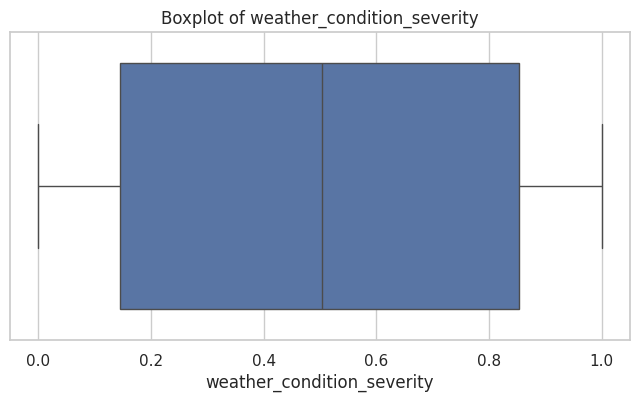

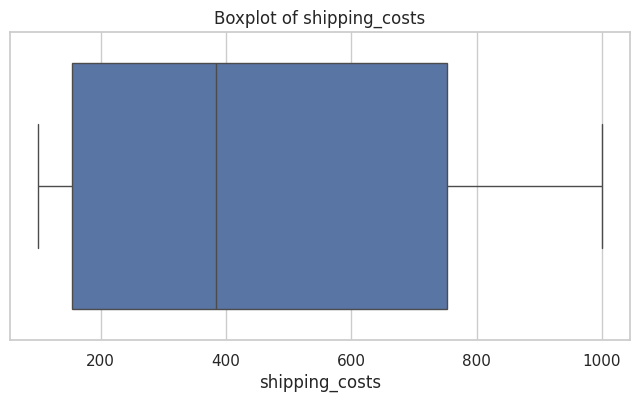

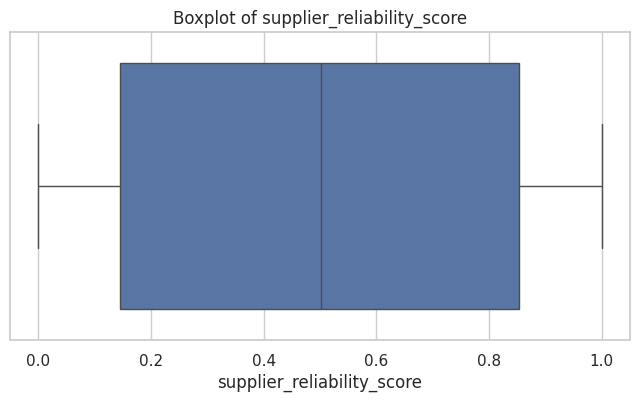

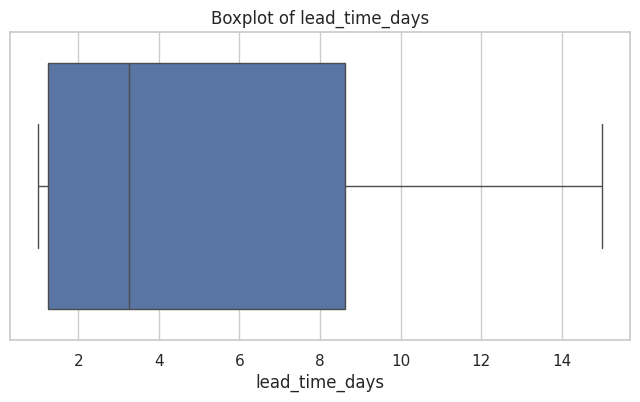

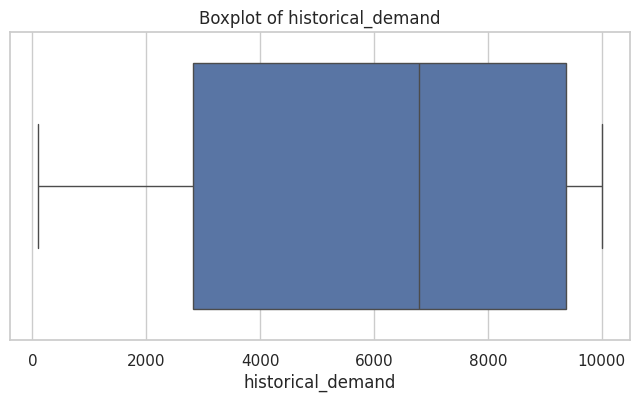

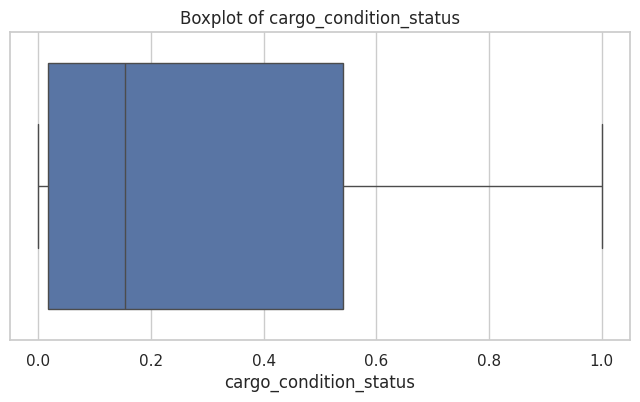

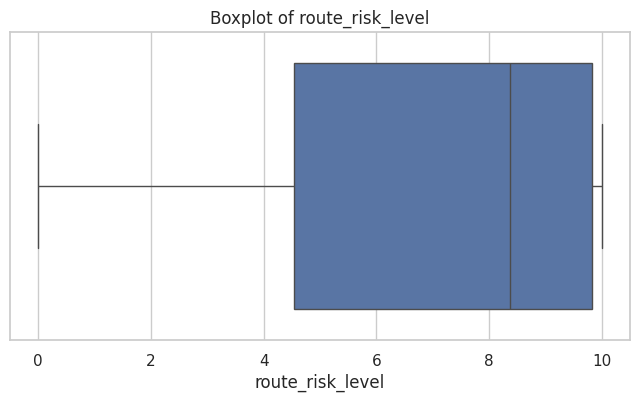

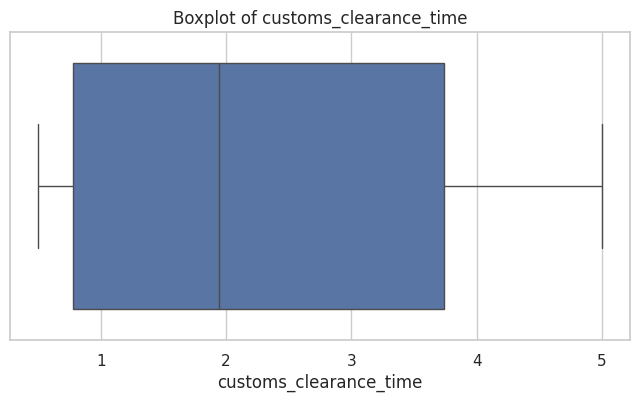

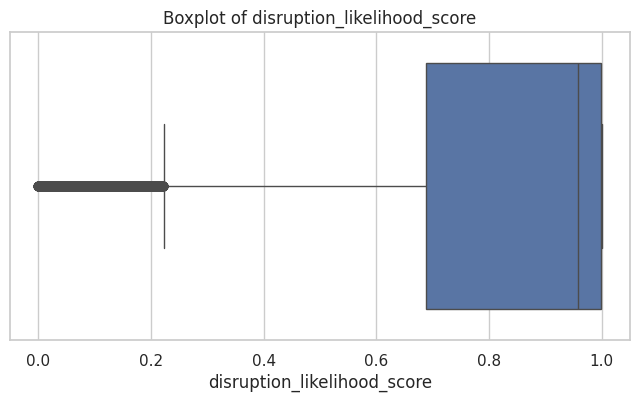

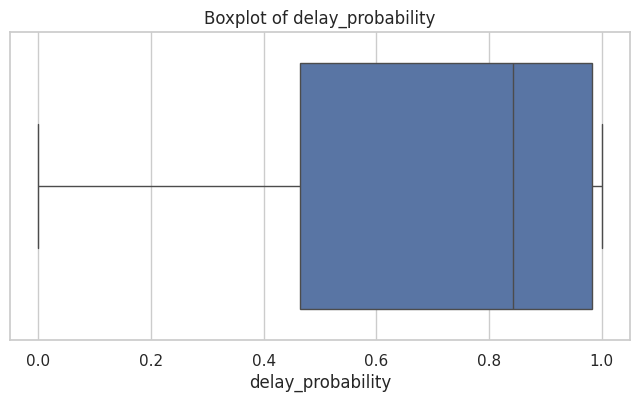

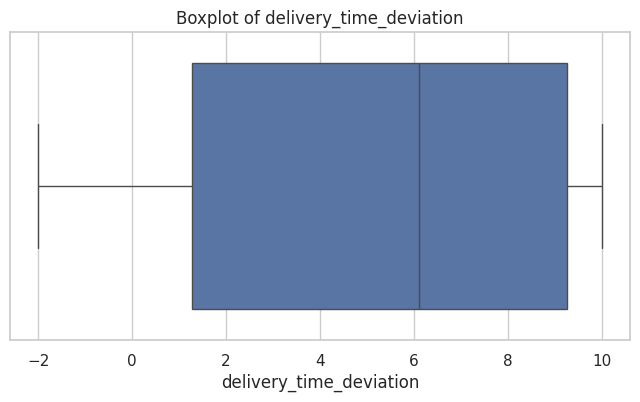


Outlier Detection
warehouse_inventory_level: 0 Outliers
handling_equipment_availability: 0 Outliers
order_fulfillment_status: 0 Outliers
weather_condition_severity: 0 Outliers
shipping_costs: 0 Outliers
supplier_reliability_score: 0 Outliers
lead_time_days: 0 Outliers
historical_demand: 0 Outliers
cargo_condition_status: 0 Outliers
route_risk_level: 0 Outliers
customs_clearance_time: 0 Outliers
disruption_likelihood_score: 5719 Outliers
delay_probability: 0 Outliers
delivery_time_deviation: 0 Outliers


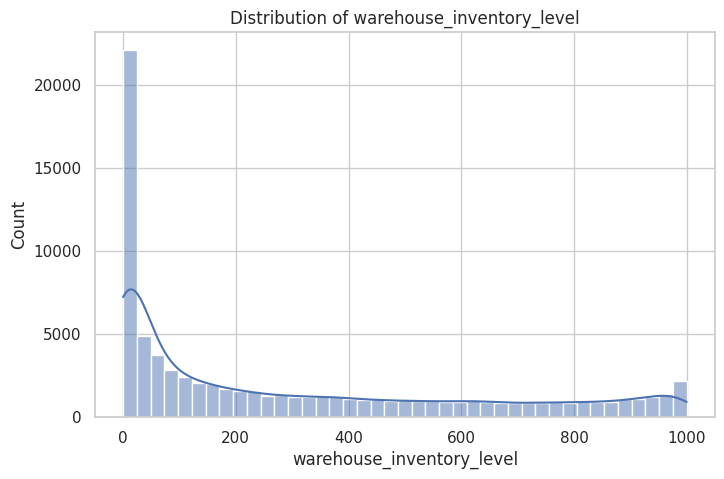

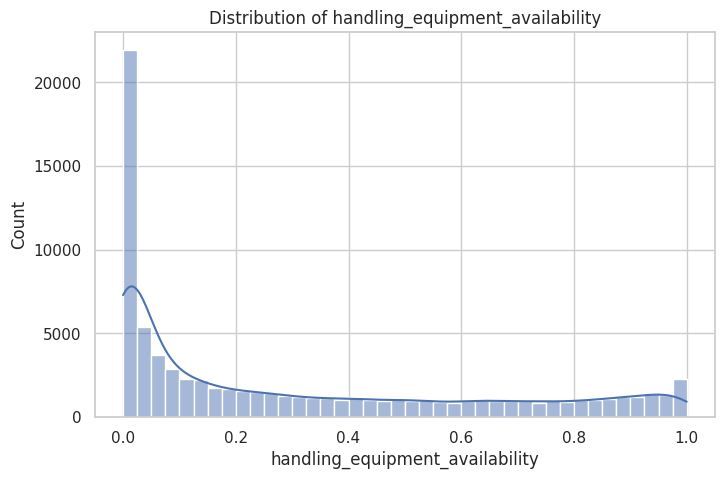

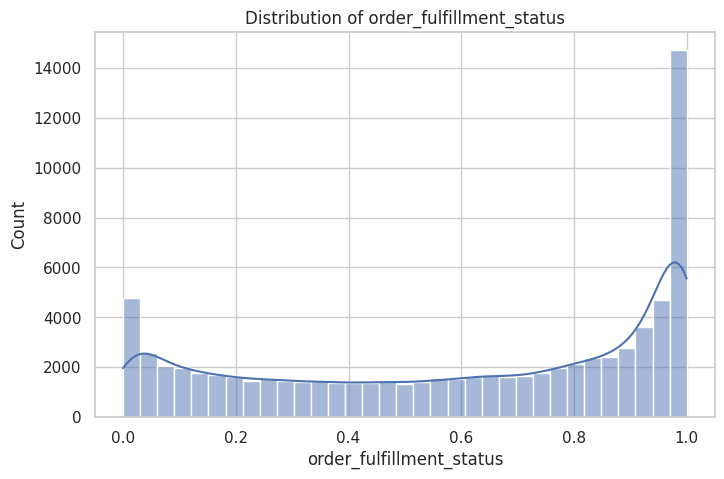

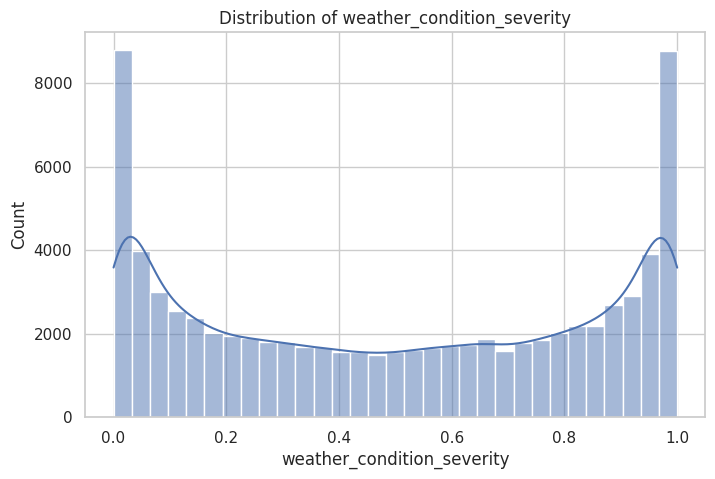

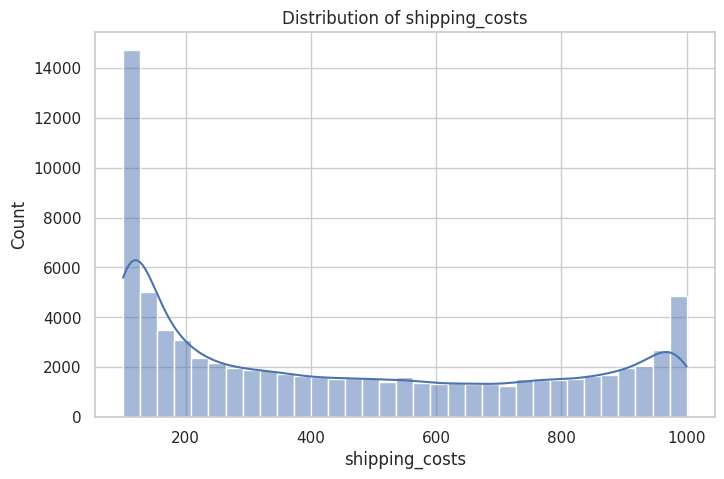

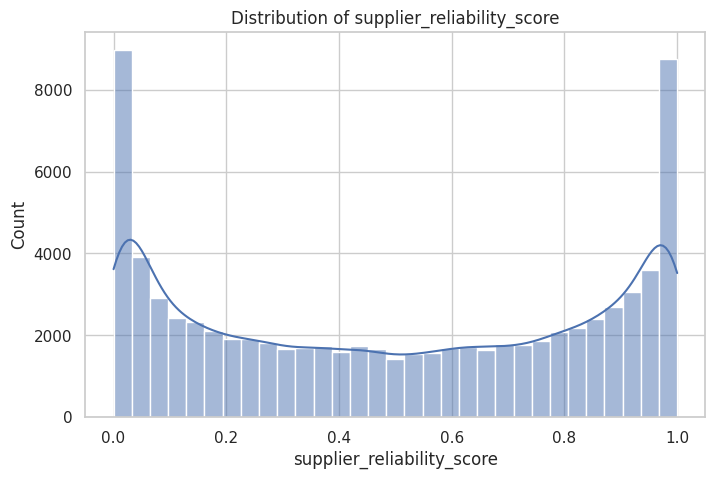

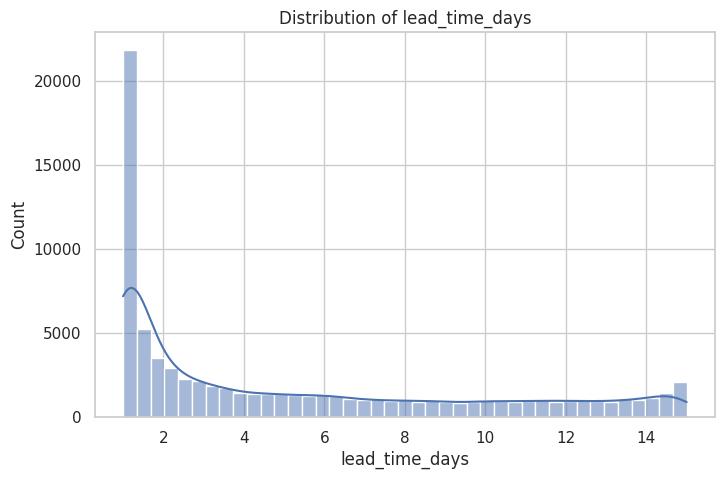

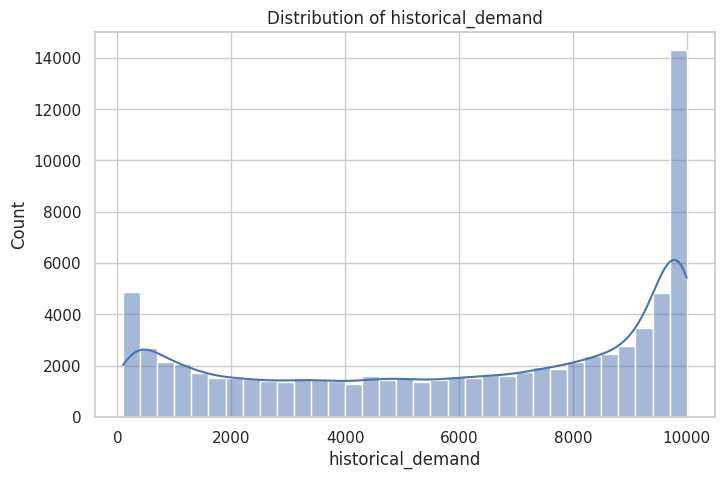

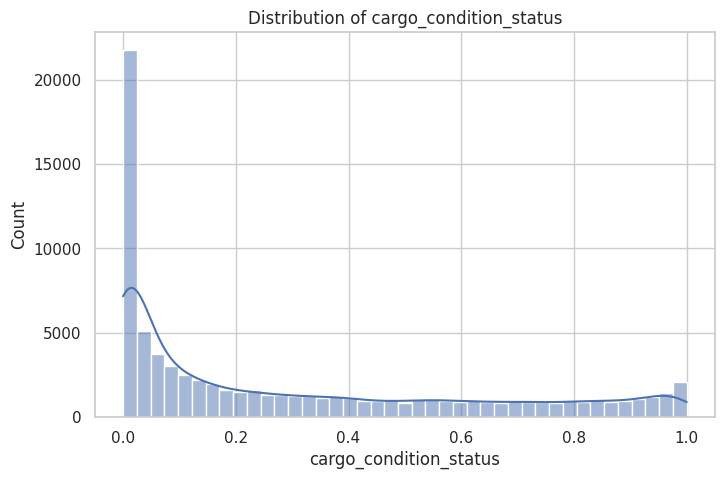

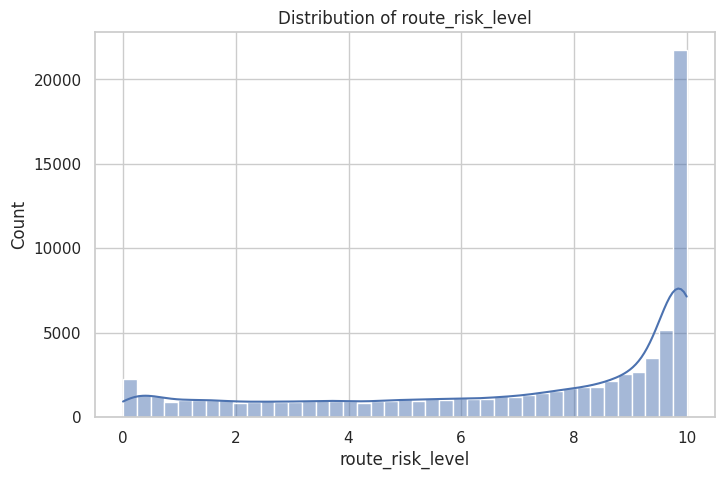

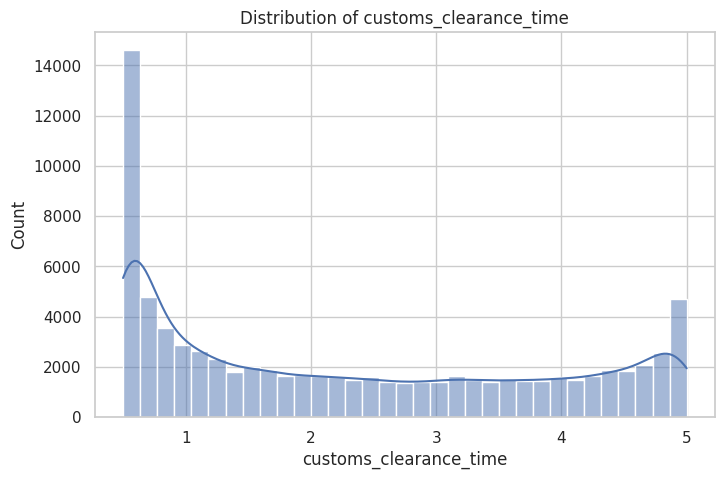

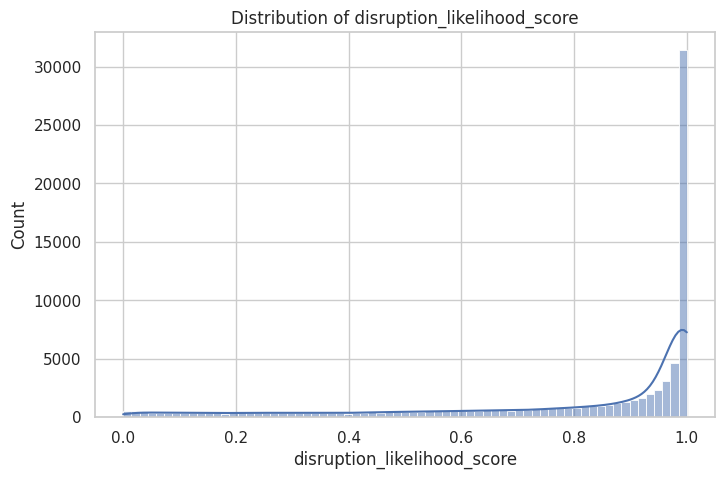

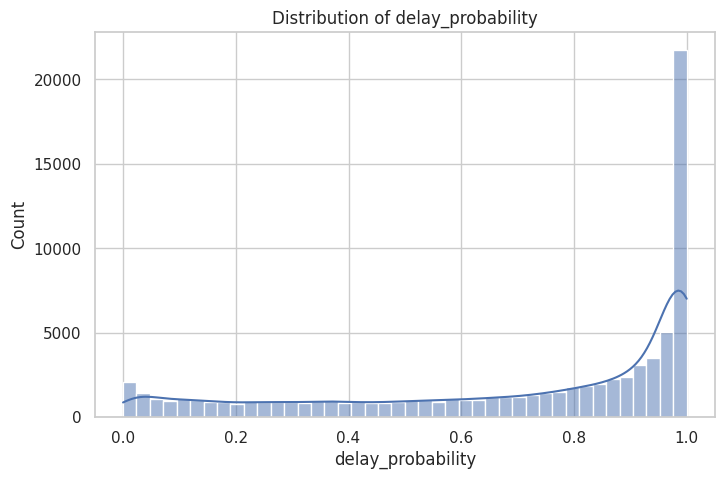

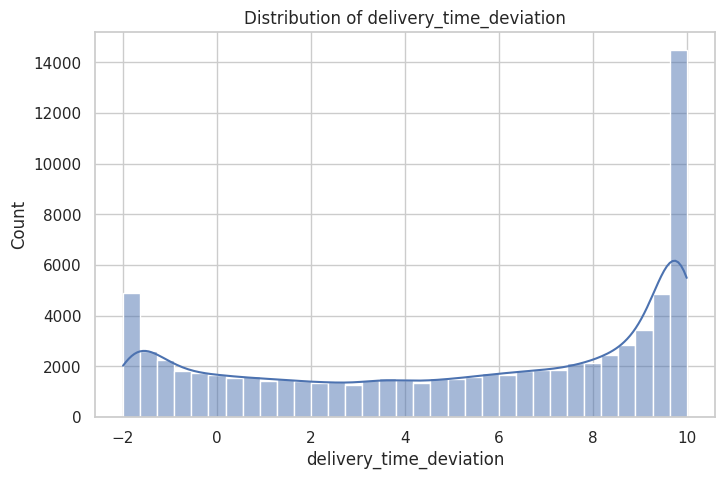

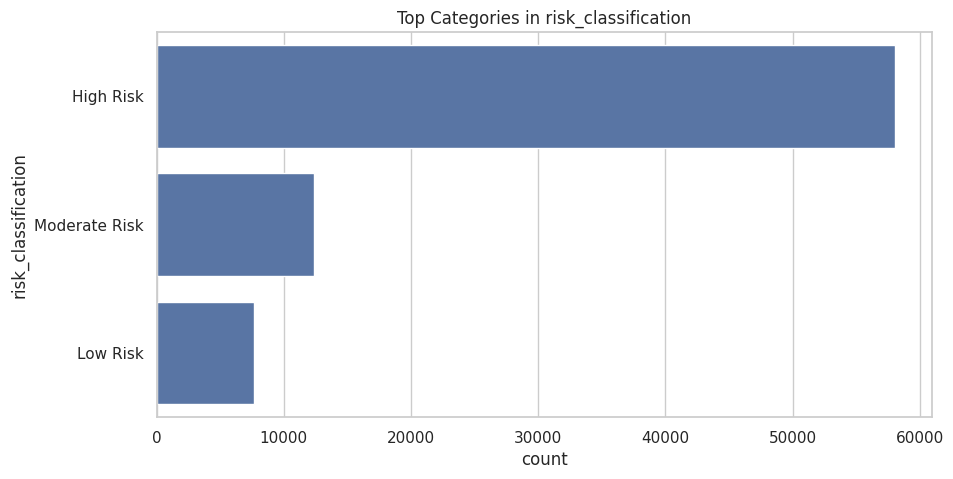

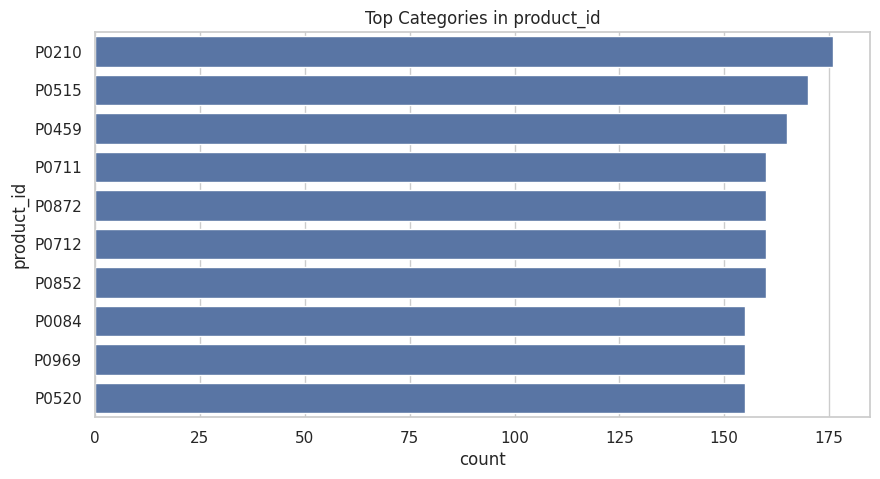

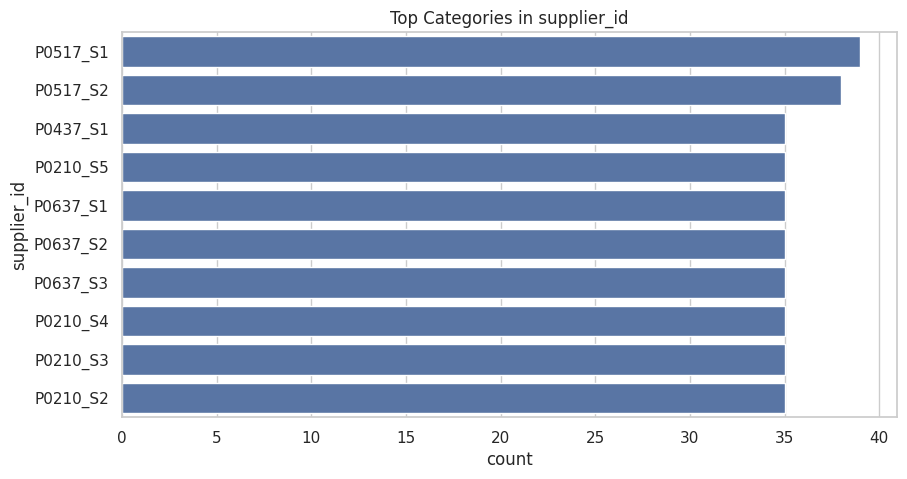

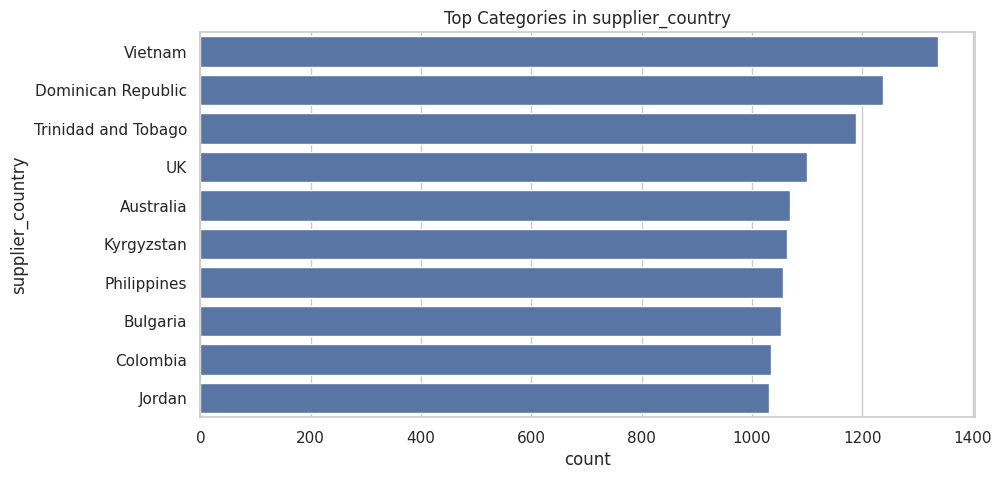


Categorical Value Counts

-------------------------
risk_classification
risk_classification
High Risk        58032
Moderate Risk    12357
Low Risk          7658
Name: count, dtype: int64

-------------------------
product_id
product_id
P0210    176
P0515    170
P0459    165
P0711    160
P0872    160
P0712    160
P0852    160
P0084    155
P0969    155
P0520    155
Name: count, dtype: int64

-------------------------
supplier_id
supplier_id
P0517_S1    39
P0517_S2    38
P0437_S1    35
P0210_S5    35
P0637_S1    35
P0637_S2    35
P0637_S3    35
P0210_S4    35
P0210_S3    35
P0210_S2    35
Name: count, dtype: int64

-------------------------
supplier_country
supplier_country
Vietnam                1338
Dominican Republic     1238
Trinidad and Tobago    1189
UK                     1099
Australia              1068
Kyrgyzstan             1064
Philippines            1056
Bulgaria               1052
Colombia               1034
Jordan                 1030
Name: count, dtype: int64


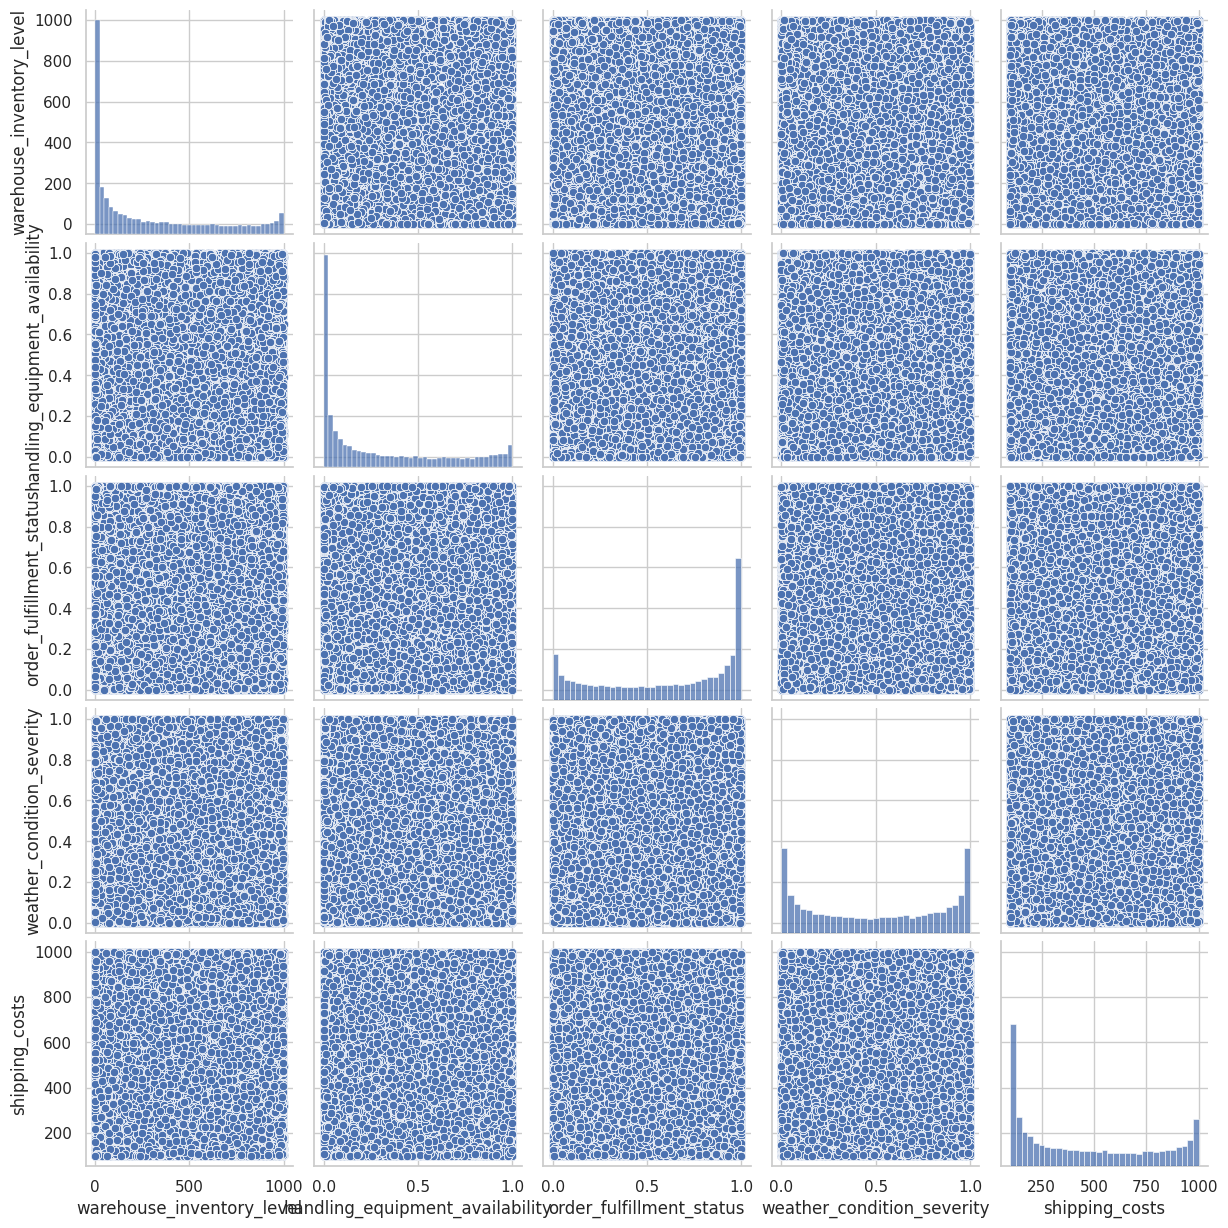


Skewness
warehouse_inventory_level          0.834577
handling_equipment_availability    0.799046
order_fulfillment_status          -0.382975
weather_condition_severity        -0.001425
shipping_costs                     0.395559
supplier_reliability_score        -0.005090
lead_time_days                     0.816816
historical_demand                 -0.377554
cargo_condition_status             0.836182
route_risk_level                  -0.815726
customs_clearance_time             0.384014
disruption_likelihood_score       -1.421683
delay_probability                 -0.845455
delivery_time_deviation           -0.378334
dtype: float64

Kurtosis
warehouse_inventory_level         -0.707057
handling_equipment_availability   -0.803703
order_fulfillment_status          -1.336796
weather_condition_severity        -1.502622
shipping_costs                    -1.328788
supplier_reliability_score        -1.501945
lead_time_days                    -0.740877
historical_demand                 -1.3363

In [4]:


# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)



df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding='latin1')

print("\nDataset Loaded Successfully!")

# ============================================================
# 3. Display Basic Information
# ============================================================

print("\nFirst 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nDataset Information")
print(df.info())

print("\nData Types")
print(df.dtypes)

# ============================================================
# 4. Summary Statistics
# ============================================================

print("\nSummary Statistics")
print(df.describe(include='all'))

# ============================================================
# 5. Missing Values
# ============================================================

print("\nMissing Values")
print(df.isnull().sum())

# Fill numerical missing values
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical missing values
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# ============================================================
# 6. Duplicate Records
# ============================================================

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates:", df.shape)

# ============================================================
# 7. Convert Data Types (if needed)
# ============================================================

date_columns = [col for col in df.columns if "date" in col.lower()]

for col in date_columns:
    try:
        df[col] = pd.to_datetime(df[col])
    except:
        pass

# ============================================================
# 8. Correlation Matrix
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# 9. Histograms
# ============================================================

numeric_df.hist(figsize=(18,15))
plt.tight_layout()
plt.show()

# ============================================================
# 10. Boxplots
# ============================================================

for col in numeric_df.columns:

    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.show()

# ============================================================
# 11. Outlier Detection (IQR Method)
# ============================================================

print("\nOutlier Detection")

for col in numeric_df.columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} Outliers")

# ============================================================
# 12. Distribution Plots
# ============================================================

for col in numeric_df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

# ============================================================
# 13. Count Plots (Categorical Columns)
# ============================================================

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns[:8]:

    plt.figure(figsize=(10,5))

    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index[:10]
    )

    plt.title(f"Top Categories in {col}")

    plt.show()

# ============================================================
# 14. Value Counts
# ============================================================

print("\nCategorical Value Counts")

for col in categorical_columns[:5]:

    print("\n-------------------------")
    print(col)
    print(df[col].value_counts().head(10))

# ============================================================
# 15. Pair Plot
# ============================================================

sample_numeric = numeric_df.iloc[:, :5]

sns.pairplot(sample_numeric)

plt.show()

# ============================================================
# 16. Skewness
# ============================================================

print("\nSkewness")

print(numeric_df.skew())

# ============================================================
# 17. Kurtosis
# ============================================================

print("\nKurtosis")

print(numeric_df.kurt())

# ============================================================
# 18. Unique Values
# ============================================================

print("\nUnique Values")

for col in df.columns:

    print(col, ":", df[col].nunique())

# ============================================================
# 19. Save Cleaned Dataset
# ============================================================

df.to_csv("Cleaned_SupplyChain_Dataset.csv", index=False)

print("\nCleaned Dataset Saved Successfully!")

# ============================================================
# 20. Final Report
# ============================================================

print("\n==============================")
print("EDA COMPLETED SUCCESSFULLY")
print("==============================")

print("Final Shape :", df.shape)

print("Missing Values :", df.isnull().sum().sum())

print("Duplicate Rows :", df.duplicated().sum())

print("Number of Columns :", len(df.columns))

print("Number of Numerical Columns :", len(numeric_df.columns))

print("Number of Categorical Columns :", len(categorical_columns))

print("==============================")